In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from experiments.datasets import Datasets

for i in Datasets:
    print(i.name, ": ", end="")
    X, l = i.data
    print(X.shape, l.shape)

print()
print("Finished.")

Synth_low : (5000, 100) (5000,)
Synth_high : (5000, 100) (5000,)
HAR : (10299, 561) (10299,)
letterrec. : (20000, 16) (20000,)
htru2 : (17898, 8) (17898,)
Mice : (1077, 68) (1077,)
TCGA : (801, 20264) (801,)
Pendigits : (10992, 16) (10992,)
Weizmann : (5701, 77760) (5701,)
Keck : (25457, 120000) (25457,)
COIL20 : (1440, 16384) (1440,)
COIL100 : (7200, 49152) (7200,)
cmu_faces : (624, 960) (624,)
Optdigits : (5620, 64) (5620,)
USPS : (9298, 256) (9298,)
MNIST : (70000, 784) (70000,)
FMNIST : (70000, 784) (70000,)
KMNIST : (70000, 784) (70000,)

Finished.


In [ ]:
import glob
import numpy as np
import pandas as pd
import re
from os.path import exists
from collections import defaultdict
from functools import partial

from clustpy.utils import evaluation_df_to_latex_table
from clustpy.utils import plot_with_transformation

from sklearn.metrics import (
    normalized_mutual_info_score as nmi,
    adjusted_mutual_info_score as ami,
    adjusted_rand_score as ari,
)
import seaborn as sns
import matplotlib.pyplot as plt

from clustpy.data import *
from experiments.helper import *

In [11]:
DATASETS_ALL = [
    ("Synth_low", load_syn("data/datasets/low_data_100.npy")),
    ("Synth_high", load_syn("data/datasets/high_data_100.npy")),
    ("HAR", load_har),
    ("Mice", apply_label(partial(load_mice_protein, return_additional_labels=True), 0)),
    ("Mice_behavior", apply_label(partial(load_mice_protein, return_additional_labels=True), 1)),
    ("Optdigits", load_optdigits),
    ("Pendigits", load_pendigits),
    ("USPS", load_usps),
    ("MNIST", load_mnist),
    ("FMNIST", load_fmnist),
    ("KMNIST", load_kmnist),
    ("ImageNet10", load_imagenet10),
    ("ImageNetDog", partial(load_imagenet_dog, breeds=None)),
    ("Weizmann", video_labels(load_video_weizmann)),
    ("Keck", video_labels(load_video_keck_gesture)),
]

In [6]:
def load_np_dataset(path):
    X = np.load(path + "_data.npy", allow_pickle=True)
    l = np.load(path + "_labels.npy", allow_pickle=True)
    X = X.reshape((len(X), -1))
    return X, l

In [12]:
DATASETS_IDs = [
    "Synth_low",
    "Synth_high",
    "HAR",
    "letterrecognition",
    "htru2",
    "Mice",
    "TCGA_HiSeq",
    # "Optdigits",
    "Pendigits",
    # "USPS",
    # "MNIST",
    # "FMNIST",
    # "KMNIST",
    "Weizmann",
    "Keck",
    "COIL20",
    "Coil100",
    "cmu_faces",
]

DATASETS_ALL = []
for dataset_id in DATASETS_IDs:
    DATASETS_ALL.append((dataset_id, load_np_dataset(f"datasets/clustpy/{dataset_id}_z")))

In [ ]:
def _standardize(data, axis=None):
    mean = np.mean(data, axis=axis)
    std = np.std(data, axis=axis)
    # if isinstance(std, np.ndarray):
    #     std[std == 0] = 1
    # elif std == 0:
    #     std = 1
    return (data - mean) / std


def standardize_X(fn):
    X, l = fn()
    X = _standardize(X, axis=0)
    return lambda *args, **kwargs: (X, l)


def standardize_X_(fn):
    X, l = fn()
    X = _standardize(X, axis=None)
    return lambda *args, **kwargs: (X, l)

In [13]:
datasets = [
    ("Synth_low", standardize_X(load_syn("data/datasets/low_data_100.npy"))),
    ("Synth_high", standardize_X(load_syn("data/datasets/high_data_100.npy"))),
    ("HAR", standardize_X(load_har)),
    ("Mice", standardize_X(load_mice_protein)),
    ("Optdigits", standardize_X_(load_optdigits)),
    ("Pendigits", standardize_X_(load_pendigits)),
    ("Weizmann", standardize_X_(video_labels(load_video_weizmann))),
    ("cmu_faces", standardize(apply_label(load_cmu_faces, 0))),
    ("TCGA_HiSeq", standardize(load_np_dataset("data/datasets/TCGA_PANCAN_HiSeq"), axis=0)),
    ("COIL20", standardize(load_coil20)),
    ("htru2", standardize_X(load_htru2)),
    ("letterrecognition", standardize(load_letterrecognition, axis=0)),
    ("Keck", standardize_X_(video_labels(load_video_keck_gesture))),
    ("Coil100", standardize(partial(load_coil100, normalize_channels=True))),
    ("USPS", standardize_X_(partial(load_usps, normalize_channels=True))),
    ("MNIST", standardize_X_(partial(load_mnist, normalize_channels=True))),
    ("FMNIST", standardize_X_(partial(load_fmnist, normalize_channels=True))),
    ("KMNIST", standardize_X_(partial(load_kmnist, normalize_channels=True))),
]

In [825]:
for dataset, fn in datasets:
    print(dataset)
    X, l = fn()
    np.save(f"data/datasets/clustpy/{dataset}_z_data.npy", X)
    np.save(f"data/datasets/clustpy/{dataset}_z_labels.npy", l)

Synth_low
Synth_high
HAR
Mice
Optdigits
Pendigits
Weizmann
cmu_faces
TCGA_HiSeq
COIL20
htru2
letterrecognition
Keck
Coil100
USPS
MNIST
FMNIST
KMNIST


In [14]:
DATASETS_ALL2 = []
for dataset, fn in DATASETS_ALL:
    DATASETS_ALL2.append((dataset, load_np_dataset(f"data/datasets/clustpy/{dataset}")))

In [15]:
DATASETS_VIDEO = [
    ("Weizmann", video_labels(load_video_weizmann)),
    ("Keck", video_labels(load_video_keck_gesture)),
]

In [115]:
DATASETS_SIMPLE = [
    ("olivetti_faces", load_olivetti_faces),
    ("cmu_faces", apply_label(load_cmu_faces, 0)),
    ("breastcancer", load_breast_cancer),
    ("MIaMIA", load_np_dataset("data/datasets/MIaMIA")),
    ("TCGA_HiSeq", load_np_dataset("data/datasets/TCGA_PANCAN_HiSeq")),
    ("COIL20", load_coil20),
    ("Coil100", partial(load_coil100, normalize_channels=True)),
    ("htru2", load_htru2),
    ("letterrecognition", load_letterrecognition),
]

In [17]:
DATASETS_SYNTH = [
    ("Synth_10_0.1", load_syn("data/datasets/synth/synth_10_0.1.npy")),
    ("Synth_50_0.1", load_syn("data/datasets/synth/synth_50_0.1.npy")),
    ("Synth_100_0.1", load_syn("data/datasets/synth/synth_100_0.1.npy")),
    ("Synth_500_0.1", load_syn("data/datasets/synth/synth_500_0.1.npy")),
    ("Synth_1000_0.1", load_syn("data/datasets/synth/synth_1000_0.1.npy")),
    ("Synth_5000_0.1", load_syn("data/datasets/synth/synth_5000_0.1.npy")),
    ("Synth_10000_0.1", load_syn("data/datasets/synth/synth_10000_0.1.npy")),
    ("Synth_50000_0.1", load_syn("data/datasets/synth/synth_50000_0.1.npy")),
    ("Synth_50000_0.2", load_syn("data/datasets/synth/synth_50000_0.2.npy")),
    ("Synth_50000_0.3", load_syn("data/datasets/synth/synth_50000_0.3.npy")),
    ("Synth_50000_0.4", load_syn("data/datasets/synth/synth_50000_0.4.npy")),
    ("Synth_50000_0.5", load_syn("data/datasets/synth/synth_50000_0.5.npy")),
    ("Synth_50000_0.6", load_syn("data/datasets/synth/synth_50000_0.6.npy")),
    ("Synth_50000_0.7", load_syn("data/datasets/synth/synth_50000_0.7.npy")),
    ("Synth_50000_0.8", load_syn("data/datasets/synth/synth_50000_0.8.npy")),
    ("Synth_50000_0.9", load_syn("data/datasets/synth/synth_50000_0.9.npy")),
]

In [ ]:
PATHS_ALL = [
    # "data_all/data/benchmarks_dc_clusterer",
    # "data_all/data/benchmarks_dc_clusterer_2",
    # "data_all/data/benchmarks2_1",
    # "data_all/data/benchmarks2_2",
    # "data_all/data/benchmarks2_3",
    # "data_all/data/benchmarks3_1",
    # "data_all/data/benchmarks3_2",
    # "data_all/data/benchmarks_f_4_1",
    # "data_all/data/benchmarks_f_4_2",
    # "data_all/data/benchmarks_w_5_1",
    # "data_all/data/benchmarks_w_5_2",
    "data_all/data_luke/benchmarks2",
    "data_all/data_luke/benchmarks2_1",
    "data_all/data_luke/benchmarks2_3",
    # "data_all/data_padme/benchmarks3_1",
    # "data_all/data_padme/benchmarks3_2",
    # "data_all/data_anakin/benchmarks_c_1",
    # "data_all/data_anakin/benchmarks_c_1_1",
    # "data_all/data_anakin/benchmarks_c_2",
    # "data_all/data_anakin/benchmarks_c_2_1",
    # "data_all/data/benchmarks_simple_4_3",
    # "data_all/data/benchmark_abalation",
    "data_all/data/benchmark_reste",
    "data_all/data/benchmark_mnist",
    # "data/benchmark*",
    "data_all/data_padme/*",
    "data_all/data_anakin/*",
    "emb",
    "ae_results/ae/",
]

In [18]:
PATHS_ALL = [
    "ae_results/ae_minibatch/",
]

In [6]:
PATHS_SYNTH = [
    "data_synth/benchmarks*",
]

In [35]:
PATHS_NEW = [
    "ae_results/ae/",
    "ae_results/ae_dens/",
    "ae_results/ae_rec/",
    # "ae_results/ae_minibatch/",
    # "ae_results/dctree/",
    # "ae_results/pca/",
    # "ae_results/rec/",
]
# PATHS_NEW = PATHS_NEW + ["data_all/" + path for path in PATHS_ALL]

In [ ]:
DATASETS = DATASETS_ALL
# DATASETS = DATASETS_SIMPLE
PATHS = PATHS_ALL

NameError: name 'DATASETS_ALL' is not defined

In [ ]:
DATASETS = DATASETS_SYNTH
PATHS = PATHS_SYNTH

# GATHER ALL DATASETS

In [ ]:
from sklearn.neighbors import NearestNeighbors


def one_nn(X, l_):  # Dataset 'X', labels with noise 'l_'
    clustered_points = X[l_ >= 0]

    if len(clustered_points) == 0:
        return l_.copy()

    unclustered_points = X[l_ < 0]
    nbrs = NearestNeighbors(n_neighbors=1).fit(clustered_points)
    if len(unclustered_points) == 0:
        return l_.copy()
    dists, inds = nbrs.kneighbors(unclustered_points)
    new_labels = l_.copy()
    inds = inds.reshape(-1)
    new_labels[l_ < 0] = l_[l_ >= 0][inds]
    return new_labels

In [ ]:
SELECTED_DATASETS_SHADE = [
    "Synth_low",
    "Synth_high",
    "HAR",
    "letterrecognition",
    "htru2",
    "Mice",
    "TCGA_HiSeq",
    "Pendigits",
    "Weizmann",
    "Keck",
    "COIL20",
    "Coil100",
    "cmu_faces",
    # "Optdigits",
]
SELECTED_DATASETS_MNIST = [
    "Optdigits",
    # "Pendigits",
    "USPS",
    "MNIST",
    "FMNIST",
    "KMNIST",
]
SELECTED_DATASETS_DC_CLUSTERER = [
    "TCGA_HiSeq",
    "htru2",
    "Weizmann",
]

SELECTED_DATASETS_ABALATION = [
    "Synth_high",
    "TCGA_HiSeq",
    "COIL20",
]

SELECTED_DATASETS = SELECTED_DATASETS_SHADE
# SELECTED_DATASETS = SELECTED_DATASETS_MNIST
# SELECTED_DATASETS = SELECTED_DATASETS_DC_CLUSTERER
# SELECTED_DATASETS = SELECTED_DATASETS_ABALATION

# DATASETS = np.concatenate((DATASETS_ALL, DATASETS_SIMPLE))
DATASETS = DATASETS_ALL
DATASETS = list(filter(lambda entry: (entry[0] in SELECTED_DATASETS), DATASETS))
sel_datasets = [x[0] for x in DATASETS]
order = [sel_datasets.index(dataset) for dataset in SELECTED_DATASETS]
DATASETS = [DATASETS[i] for i in order]

METRICS = ["NMI", "ARI", "noise", "n_clusters"]

ALGORITHMS_ALL = [
    "SHADE", 
    "SHADE_S",
    "SHADE_w",
    "SHADE_emb",
    "SHADE_1nn_emb",
    "DDC",
    "DipDECK",
    "DipEncoder",
    "DCN",
    "DEC",
    "IDEC",
]

ALGORITHMS_ALL_ = [
    "SHADE",
    "SHADE_1nn",
    # "SHADE_1nn_emb",
    # "SHADE_single",
    "DDC",
    "DipDECK",
    "DipEncoder",
    "DCN",
    "DEC",
    "IDEC",
]

NameError: name 'DATASETS_ALL' is not defined

In [22]:
METRICS = ["NMI", "ARI", "noise", "n_clusters"]

In [24]:
ALGORITHMS_ALL = [
    "SHADE_S",
    "SHADE_w",
    "DCTree_Clusterer",
]
ALGORITHMS_ALL_ = [
    "SHADE",
    "SHADE_1nn",
    "DCTree_Clusterer",
]

In [13]:
ALGORITHMS_ALL = [
    "SHADE_3",
    "SHADE_4",
    "SHADE_S",
    "SHADE_w",
    "SHADE_6",
    "SHADE_7",
]
ALGORITHMS_ALL_ = [
    "SHADE_3",
    "SHADE_4",
    "SHADE",
    "SHADE_6",
    "SHADE_7",
]

In [77]:
ALGORITHMS_ALL = [
    "SHADE_S",
    "SHADE_w",
    "SHADE_rec",
    "SHADE_dens",
]
ALGORITHMS_ALL_ = [
    "SHADE",
    "SHADE_1nn",
    "SHADE_rec",
    "SHADE_rec_1nn",
    "SHADE_dens",
    "SHADE_dens_1nn",
]

In [20]:
one_nn_flag = False
noise_each_cluster = False

In [156]:
PATHS_NEW[3]

'ae_results/rec/'

In [88]:
from dcsi import dcsiscore

In [99]:
_, l = load_np_dataset(f"data/datasets/clustpy/Synth_low_z")()

file_path = "./ae_results/ae/ALL/Labels/label_Synth_low_ALL_128_10_SHADE_9.csv"
emb_path = (
    file_path.replace("Labels", "embs").replace("label_", "").replace("_ALL_128_10_SHADE", "")
)
emb = np.array(pd.read_csv(emb_path, header=None))
dcsiscore(emb, l)

0.9661615449391232

In [36]:
data_ext = {}

for dataset, fn in DATASETS_ALL:
    print(dataset)
    X, l = fn

    data_ext[dataset, "mean"] = {}
    data_ext[dataset, "std"] = {}

    # for path in PATHS_ALL:
    for path in PATHS_NEW:
        file_paths = glob.glob("./" + path + "/*/Labels/label_" + dataset + "_ALL*.csv")
        file_paths = file_paths + (glob.glob("./" + path + "/*/Labels/label_" + dataset + "_128_10_*.csv"))
        algorithms = map(
            lambda str: (re.search(r".*128_10_(.*)_(\d).csv", str).group(1), str), file_paths
        )
        algorithms = list(algorithms)

        alg_dict = defaultdict(list)
        for alg_name, file_path in algorithms:
            # if path == "emb" and alg_name == "SHADE":
            #     alg_dict["SHADE"].append(file_path)
            # elif alg_name in ["SHADE", "SHADE_w", "SHADE_S", "SHADE_emb"]:
            #     continue
            # else:

            # if path.find("pca") != -1:
            #     alg_name = "PCA+" + alg_name
            # elif path.find("rec") != -1:
            #     alg_name = "AE+" + alg_name
            # alg_dict[alg_name].append(file_path)

            if path.find("ae_dens") != -1:
                alg_name = alg_name + "_dens"
            elif path.find("ae_rec") != -1:
                alg_name = alg_name + "_rec"
            alg_dict[alg_name].append(file_path)

        alg_dict = sorted(alg_dict.items())

        # print([alg_name for alg_name, _ in alg_dict])
        # print()

        for alg_name, paths_ in alg_dict:

            # if alg_name in ["SHADE", "SHADE_w", "SHADE_S", "SHADE_emb"] and dataset == "Keck":
            #     print(paths_)

            # if alg_name not in ALGORITHMS_ALL:
            #     continue

            # if alg_name in ["SHADE_w", "SHADE_S", "SHADE_emb"]:
            # if alg_name in ["SHADE_S"]:
            #     alg_name = "SHADE"

            DCSIs = []
            NMIs = []
            ARIs = []
            NOISEs = []
            n_clusters = []
            NMIs_ = []
            ARIs_ = []
            NMIs__ = []
            ARIs__ = []
            for file_path in paths_:
                # print(file_path)
                l_ = np.array(pd.read_csv(file_path, header=None)).reshape(-1)
                # emb_path = file_path \
                #     .replace("Labels", "embs") \
                #     .replace("label_", "") \
                #     .replace("_ALL_128_10_SHADE", "")
                # emb = np.array(pd.read_csv(emb_path, header=None))
                # DCSIs.append(dcsiscore(emb, l))

                n_clusters.append(len(set(l_[l_ >= 0])))
                NOISEs.append(len(np.where(l_ == -1)[0]) / len(l_))
                NMIs.append(nmi(l[l_ != -1], l_[l_ != -1]))
                ARIs.append(ari(l[l_ != -1], l_[l_ != -1]))

                if (alg_name.find("SHADE") != -1 or alg_name in ["DCTree"]) and one_nn_flag:
                    l_ = np.array(pd.read_csv(file_path, header=None)).reshape(-1)
                    if exists(file_path + "_1nn.npy"):
                        l_ = np.array(np.load(file_path + "_1nn.npy")).reshape(-1)
                    else:
                        l_ = one_nn(X, l_)
                        np.save(file_path + "_1nn", l_)

                    NMIs_.append(nmi(l[l_ != -1], l_[l_ != -1]))
                    ARIs_.append(ari(l[l_ != -1], l_[l_ != -1]))

                if alg_name.find("SHADE") != -1 and noise_each_cluster:
                    l_ = np.array(pd.read_csv(file_path, header=None)).reshape(-1)

                    n_clust = len(set(l_[l_ >= 0]))
                    ind = np.where(l_ == -1)[0]
                    for i in ind:
                        l_[i] = n_clust
                        n_clust += 1

                    NMIs__.append(nmi(l[l_ != -1], l_[l_ != -1]))
                    ARIs__.append(ari(l[l_ != -1], l_[l_ != -1]))

            print("  ", alg_name, len(NMIs))

            if "NMI" in METRICS:
                if np.mean(NOISEs) > 0.99999999:
                    data_ext[(dataset, "mean")][(alg_name, "NMI")] = 0.0
                    data_ext[(dataset, "std")][(alg_name, "NMI")] = 0.0
                else:
                    data_ext[(dataset, "mean")][(alg_name, "NMI")] = np.mean(NMIs)
                    data_ext[(dataset, "std")][(alg_name, "NMI")] = np.std(NMIs)
            if "ARI" in METRICS:
                if np.mean(NOISEs) > 0.99999999:
                    data_ext[(dataset, "mean")][(alg_name, "ARI")] = 0.0
                    data_ext[(dataset, "std")][(alg_name, "ARI")] = 0.0
                else:
                    data_ext[(dataset, "mean")][(alg_name, "ARI")] = np.mean(ARIs)
                    data_ext[(dataset, "std")][(alg_name, "ARI")] = np.std(ARIs)
            if "noise" in METRICS:
                data_ext[(dataset, "mean")][(alg_name, "noise")] = np.mean(NOISEs)
                data_ext[(dataset, "std")][(alg_name, "noise")] = np.std(NOISEs)
            if "n_clusters" in METRICS:
                data_ext[(dataset, "mean")][(alg_name, "n_clusters")] = np.mean(n_clusters)
                data_ext[(dataset, "std")][(alg_name, "n_clusters")] = np.std(n_clusters)

                if alg_name in ["DipEncoder", "DCN", "DEC", "IDEC"] and np.mean(n_clusters) == len(set(l[l >= 0])) and np.std(n_clusters) == 0:
                    data_ext[(dataset, "mean")][(alg_name, "n_clusters")] = np.nan
                    data_ext[(dataset, "std")][(alg_name, "n_clusters")] = np.nan

            data_ext[(dataset, "mean")][(alg_name, "runs")] = len(paths_)
            data_ext[(dataset, "mean")][(alg_name, "DCSI")] = np.mean(DCSIs)
            data_ext[(dataset, "std")][(alg_name, "DCSI")] = np.std(DCSIs)

            if alg_name.find("SHADE") != -1 and one_nn_flag:
                alg_name += "_1nn"
                if "NMI" in METRICS:
                    data_ext[(dataset, "mean")][(alg_name, "NMI")] = np.mean(NMIs_)
                    data_ext[(dataset, "std")][(alg_name, "NMI")] = np.std(NMIs_)
                if "ARI" in METRICS:
                    data_ext[(dataset, "mean")][(alg_name, "ARI")] = np.mean(ARIs_)
                    data_ext[(dataset, "std")][(alg_name, "ARI")] = np.std(ARIs_)
                if "noise" in METRICS:
                    data_ext[(dataset, "mean")][(alg_name, "noise")] = 0
                    data_ext[(dataset, "std")][(alg_name, "noise")] = 0
                if "n_clusters" in METRICS:
                    data_ext[(dataset, "mean")][(alg_name, "n_clusters")] = np.mean(n_clusters)
                    data_ext[(dataset, "std")][(alg_name, "n_clusters")] = np.std(n_clusters)
                data_ext[(dataset, "mean")][(alg_name, "runs")] = len(paths_)
                data_ext[(dataset, "mean")][(alg_name, "DCSI")] = np.mean(DCSIs)
                data_ext[(dataset, "std")][(alg_name, "DCSI")] = np.std(DCSIs)
                alg_name = "SHADE"

            if alg_name.find("SHADE") != -1 and noise_each_cluster:
                alg_name += "_single"
                if "NMI" in METRICS:
                    data_ext[(dataset, "mean")][(alg_name, "NMI")] = np.mean(NMIs__)
                    data_ext[(dataset, "std")][(alg_name, "NMI")] = np.std(NMIs__)
                if "ARI" in METRICS:
                    data_ext[(dataset, "mean")][(alg_name, "ARI")] = np.mean(ARIs__)
                    data_ext[(dataset, "std")][(alg_name, "ARI")] = np.std(ARIs__)
                if "noise" in METRICS:
                    data_ext[(dataset, "mean")][(alg_name, "noise")] = 0
                    data_ext[(dataset, "std")][(alg_name, "noise")] = 0
                if "n_clusters" in METRICS:
                    data_ext[(dataset, "mean")][(alg_name, "n_clusters")] = np.mean(n_clusters)
                    data_ext[(dataset, "std")][(alg_name, "n_clusters")] = np.std(n_clusters)
                data_ext[(dataset, "mean")][(alg_name, "runs")] = len(paths_)
                data_ext[(dataset, "mean")][(alg_name, "DCSI")] = np.mean(DCSIs)
                data_ext[(dataset, "std")][(alg_name, "DCSI")] = np.std(DCSIs)
                alg_name = "SHADE"


df = pd.DataFrame.from_dict(data_ext, orient="index")

Synth_low
   SHADE 10


/export/share/pascalw777dm/miniconda3/envs/stuff/lib/python3.12/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/export/share/pascalw777dm/miniconda3/envs/stuff/lib/python3.12/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/export/share/pascalw777dm/miniconda3/envs/stuff/lib/python3.12/site-packages/numpy/core/_methods.py:206: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/export/share/pascalw777dm/miniconda3/envs/stuff/lib/python3.12/site-packages/numpy/core/_methods.py:163: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/export/share/pascalw777dm/miniconda3/envs/stuff/lib/python3.12/site-packages/numpy/core/_methods.py:198: RuntimeWarning: invalid value encountered in scalar divide
  ret =

   SHADE_dens 10
   SHADE_rec 10
Synth_high


/export/share/pascalw777dm/miniconda3/envs/stuff/lib/python3.12/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/export/share/pascalw777dm/miniconda3/envs/stuff/lib/python3.12/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/export/share/pascalw777dm/miniconda3/envs/stuff/lib/python3.12/site-packages/numpy/core/_methods.py:206: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/export/share/pascalw777dm/miniconda3/envs/stuff/lib/python3.12/site-packages/numpy/core/_methods.py:163: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/export/share/pascalw777dm/miniconda3/envs/stuff/lib/python3.12/site-packages/numpy/core/_methods.py:198: RuntimeWarning: invalid value encountered in scalar divide
  ret =

   SHADE 10
   SHADE_dens 10


...

/export/share/pascalw777dm/miniconda3/envs/stuff/lib/python3.12/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/export/share/pascalw777dm/miniconda3/envs/stuff/lib/python3.12/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/export/share/pascalw777dm/miniconda3/envs/stuff/lib/python3.12/site-packages/numpy/core/_methods.py:206: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/export/share/pascalw777dm/miniconda3/envs/stuff/lib/python3.12/site-packages/numpy/core/_methods.py:163: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/export/share/pascalw777dm/miniconda3/envs/stuff/lib/python3.12/site-packages/numpy/core/_methods.py:198: RuntimeWarning: invalid value encountered in scalar divide
  ret =

   SHADE_rec 10
cmu_faces
   SHADE 10


/export/share/pascalw777dm/miniconda3/envs/stuff/lib/python3.12/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/export/share/pascalw777dm/miniconda3/envs/stuff/lib/python3.12/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/export/share/pascalw777dm/miniconda3/envs/stuff/lib/python3.12/site-packages/numpy/core/_methods.py:206: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/export/share/pascalw777dm/miniconda3/envs/stuff/lib/python3.12/site-packages/numpy/core/_methods.py:163: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/export/share/pascalw777dm/miniconda3/envs/stuff/lib/python3.12/site-packages/numpy/core/_methods.py:198: RuntimeWarning: invalid value encountered in scalar divide
  ret =

   SHADE_dens 10
   SHADE_rec 10


/export/share/pascalw777dm/miniconda3/envs/stuff/lib/python3.12/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/export/share/pascalw777dm/miniconda3/envs/stuff/lib/python3.12/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/export/share/pascalw777dm/miniconda3/envs/stuff/lib/python3.12/site-packages/numpy/core/_methods.py:206: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/export/share/pascalw777dm/miniconda3/envs/stuff/lib/python3.12/site-packages/numpy/core/_methods.py:163: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/export/share/pascalw777dm/miniconda3/envs/stuff/lib/python3.12/site-packages/numpy/core/_methods.py:198: RuntimeWarning: invalid value encountered in scalar divide
  ret =

In [87]:
"./ae_results/ae/ALL/Labels/label_Synth_low_ALL_128_10_SHADE_2.csv" \
    .replace("Labels", "embs") \
    .replace("label_", "") \
    .replace("_ALL_128_10_SHADE", "")

'./ae_results/ae/ALL/embs/Synth_low_2.csv'

In [13]:
data_ext

{}

In [28]:
# DATASETS_ = [
#     ("Synth_low", 0),
#     ("Synth_high", 0),
#     ("COIL20", 0),
# ]
ALGORITHMS_ALL_ = ["SHADE_" + str(batchsize) for batchsize in [100, 300, 500, 700, 900]]
# ALGORITHMS_ALL_ = ["SHADE", "DCTree"]
# ALGORITHMS_ALL_ = [
#     "SHADE",
#     "SHADE_single",
#     "SHADE_1nn",
#     "PCA+k-Means",
#     "PCA+HDBSCAN",
#     "AE+k-Means",
#     "AE+HDBSCAN",
# ]
# ALGORITHMS_ALL_ = ["SHADE_1nn", "SHADE_rec_1nn", "SHADE_dens_1nn"]

DATASETS = [
    ("Synth_high", ""),
    ("TCGA_HiSeq",""),
    ("COIL20",""),
]

# DATASETS = [
#     ("Synth_low", ""),
#     ("HAR",""),
#     ("letterrecognition",""),
#     ("TCGA_HiSeq",""),
# ]

In [37]:
df

SHADE                                             \
                             NMI       ARI     noise  n_clusters  runs DCSI   
Synth_low         mean  0.998554  0.998682  0.004780   10.300000  10.0  NaN   
                  std   0.002936  0.002745  0.005064    0.458258   NaN  NaN   
Synth_high        mean  0.980236  0.983424  0.031480   13.000000  10.0  NaN   
                  std   0.011002  0.010273  0.012003    1.483240   NaN  NaN   
HAR               mean  0.595240  0.376185  0.066676    4.700000  10.0  NaN   
                  std   0.062790  0.066607  0.075210    3.034798   NaN  NaN   
letterrecognition mean  0.758564  0.435118  0.508610  114.100000  10.0  NaN   
                  std   0.007717  0.018375  0.012214    5.575841   NaN  NaN   
htru2             mean  0.472556  0.572000  0.113180    4.900000  10.0  NaN   
                  std   0.308195  0.369057  0.064430    2.343075   NaN  NaN   
Mice              mean  0.539702  0.316716  0.267038   10.100000  10.0  NaN   
                  std   0.065067  0.055527  0.083889    2.624881   NaN  NaN   
TCGA_HiSeq        mean  0.927239  0.893838  0.178652    6.000000  10.0  NaN   
                  std   0.034442  0.061672  0.065241    1.183216   NaN  NaN   
Pendigits         mean  0.884634  0.840444  0.174063   20.600000  10.0  NaN   
                  std   0.004316  0.006814  0.014503    1.200000   NaN  NaN   
Weizmann          mean  0.866551  0.600120  0.156604   56.200000  10.0  NaN   
                  std   0.011389  0.037391  0.020898    2.271563   NaN  NaN   
Keck              mean  0.662636  0.090804  0.248682  230.600000  10.0  NaN   
                  std   0.006383  0.004646  0.012801   13.108776   NaN  NaN   
COIL20            mean  0.949883  0.856529  0.138333   17.100000  10.0  NaN   
                  std   0.012602  0.038575  0.019878    0.830662   NaN  NaN   
Coil100           mean  0.945258  0.775940  0.234028   79.500000  10.0  NaN   
                  std   0.009611  0.045259  0.019114    4.432832   NaN  NaN   
cmu_faces         mean  0.687741  0.397577  0.190385   10.300000  10.0  NaN   
                  std   0.033041  0.045924  0.047154    1.268858   NaN  NaN   

                       SHADE_dens                                             \
                              NMI       ARI     noise  n_clusters  runs DCSI   
Synth_low         mean   0.991493  0.988606  0.027140   10.500000  10.0  NaN   
                  std    0.008246  0.015252  0.022312    0.921954   NaN  NaN   
Synth_high        mean   0.972161  0.977090  0.037500   14.100000  10.0  NaN   
                  std    0.015288  0.013351  0.010923    2.426932   NaN  NaN   
HAR               mean   0.556586  0.332521  0.002690    2.000000  10.0  NaN   
                  std    0.000319  0.000061  0.001858    0.000000   NaN  NaN   
letterrecognition mean   0.762141  0.448815  0.544050  101.800000  10.0  NaN   
                  std    0.006863  0.019856  0.018016    5.035871   NaN  NaN   
htru2             mean   0.388091  0.518499  0.131758    9.700000  10.0  NaN   
                  std    0.193408  0.256045  0.051033    3.377869   NaN  NaN   
Mice              mean   0.535624  0.303728  0.339276   13.900000  10.0  NaN   
                  std    0.173510  0.113267  0.108324    4.805206   NaN  NaN   
TCGA_HiSeq        mean   0.914210  0.882491  0.184769    5.900000  10.0  NaN   
                  std    0.017999  0.024806  0.070164    0.538516   NaN  NaN   
Pendigits         mean   0.885623  0.846970  0.165529   18.500000  10.0  NaN   
                  std    0.007332  0.013804  0.021184    1.431782   NaN  NaN   
Weizmann          mean   0.873316  0.600698  0.162673   57.000000  10.0  NaN   
                  std    0.011025  0.070573  0.016148    3.000000   NaN  NaN   
Keck              mean   0.664865  0.093428  0.247594  229.600000  10.0  NaN   
                  std    0.003876  0.003619  0.021841    6.959885   NaN  NaN   
COIL20            mean   0.936695  0.848069  0.141806 

In [33]:
datanames = []
for name, path in DATASETS:
    datanames.append((name, "mean"))
    datanames.append((name, "std"))

df2 = df.reindex(datanames)
df2 = df2.reindex(columns=df2.columns.reindex(ALGORITHMS_ALL_, level=0)[0])
df2 = df2.reindex(columns=df2.columns.reindex(["ARI", "NMI", "noise", "n_clusters"], level=1)[0])
# df2 = df2.reindex(columns=df2.columns.reindex(["ARI", "NMI", "DCSI"], level=1)[0])
df2.round(3)

SHADE_100                          SHADE_300                \
                      ARI    NMI  noise n_clusters       ARI    NMI  noise   
Synth_high mean     0.968  0.953  0.043     20.600     0.985  0.980  0.028   
           std      0.013  0.021  0.020      5.103     0.006  0.007  0.014   
TCGA_HiSeq mean     0.867  0.913  0.223      6.400     0.828  0.876  0.233   
           std      0.072  0.043  0.050      0.917     0.060  0.046  0.092   
COIL20     mean     0.776  0.913  0.140     17.900     0.841  0.940  0.157   
           std      0.084  0.026  0.034      2.071     0.050  0.016  0.021   

                           SHADE_500                          SHADE_700  \
                n_clusters       ARI    NMI  noise n_clusters       ARI   
Synth_high mean     13.700     0.984  0.979  0.030     13.700     0.979   
           std       1.418     0.006  0.006  0.017      1.487     0.011   
TCGA_HiSeq mean      5.700     0.858  0.895  0.273      6.000     0.882   
           std       1.005     0.062  0.038  0.057      1.000     0.046   
COIL20     mean     17.900     0.852  0.943  0.136     16.900     0.827   
           std       1.578     0.019  0.010  0.020      0.700     0.043   

                                         SHADE_900                           
                   NMI  noise n_clusters       ARI    NMI  noise n_clusters  
Synth_high mean  0.974  0.041     14.100     0.977  0.971  0.031     14.400  
           std   0.013  0.014      2.468     0.012  0.014  0.011      1.800  
TCGA_HiSeq mean  0.916  0.262      5.800     0.900  0.935  0.221      6.300  
           std   0.032  0.079      0.600     0.042  0.025  0.051      0.781  
COIL20     mean  0.937  0.148     16.700     0.832  0.936  0.130     16.700  
           std   0.014  0.019      1.552     0.048  0.017  0.022      0.900

In [34]:
df2_mean = df2.mean()
df2_mean = pd.DataFrame(data=df2_mean).transpose()
# print(df2_mean.to_latex())
df2_mean.round(3)*100

SHADE_100                        SHADE_300                        SHADE_500  \
        ARI   NMI noise n_clusters       ARI   NMI noise n_clusters       ARI   
0      46.3  47.8   8.5      883.2      46.2  47.7   9.1      688.3      46.4   

                         SHADE_700                        SHADE_900        \
    NMI noise n_clusters       ARI   NMI noise n_clusters       ARI   NMI   
0  47.9   8.9      663.1      46.4  48.1   9.4      687.0      46.8  48.3   

                    
  noise n_clusters  
0   7.8      681.4

In [39]:
import pickle

# with open("dcsi_values.pkl", "wb") as f:
#     pickle.dump(data_ext, f)

with open("benchmarks/dcsi_values.pkl", "rb") as f:
    loaded_dict = pickle.load(f)
df = pd.DataFrame.from_dict(loaded_dict, orient="index")
df

SHADE                                        \
                             NMI       ARI     noise  n_clusters  runs   
Synth_low         mean  0.998554  0.998682  0.004780   10.300000  10.0   
                  std   0.002936  0.002745  0.005064    0.458258   NaN   
Synth_high        mean  0.980236  0.983424  0.031480   13.000000  10.0   
                  std   0.011002  0.010273  0.012003    1.483240   NaN   
HAR               mean  0.595240  0.376185  0.066676    4.700000  10.0   
                  std   0.062790  0.066607  0.075210    3.034798   NaN   
letterrecognition mean  0.758564  0.435118  0.508610  114.100000  10.0   
                  std   0.007717  0.018375  0.012214    5.575841   NaN   
htru2             mean  0.472556  0.572000  0.113180    4.900000  10.0   
                  std   0.308195  0.369057  0.064430    2.343075   NaN   
Mice              mean  0.539702  0.316716  0.267038   10.100000  10.0   
                  std   0.065067  0.055527  0.083889    2.624881   NaN   
TCGA_HiSeq        mean  0.927239  0.893838  0.178652    6.000000  10.0   
                  std   0.034442  0.061672  0.065241    1.183216   NaN   
Pendigits         mean  0.884634  0.840444  0.174063   20.600000  10.0   
                  std   0.004316  0.006814  0.014503    1.200000   NaN   
Weizmann          mean  0.866551  0.600120  0.156604   56.200000  10.0   
                  std   0.011389  0.037391  0.020898    2.271563   NaN   
Keck              mean  0.662636  0.090804  0.248682  230.600000  10.0   
                  std   0.006383  0.004646  0.012801   13.108776   NaN   
COIL20            mean  0.949883  0.856529  0.138333   17.100000  10.0   
                  std   0.012602  0.038575  0.019878    0.830662   NaN   
Coil100           mean  0.945258  0.775940  0.234028   79.500000  10.0   
                  std   0.009611  0.045259  0.019114    4.432832   NaN   
cmu_faces         mean  0.687741  0.397577  0.190385   10.300000  10.0   
                  std   0.033041  0.045924  0.047154    1.268858   NaN   

                                 SHADE_1nn                              ...  \
                            DCSI       NMI       ARI noise  n_clusters  ...   
Synth_low         mean  0.974998  0.995722  0.996587     0   10.300000  ...   
                  std   0.004714  0.003974  0.004589     0    0.458258  ...   
Synth_high        mean  0.959359  0.971667  0.972827     0   13.000000  ...   
                  std   0.009125  0.013566  0.015347     0    1.483240  ...   
HAR               mean  0.483126  0.587985  0.377862     0    4.700000  ...   
                  std   0.052271  0.057167  0.071732     0    3.034798  ...   
letterrecognition mean  0.230129  0.575688  0.229774     0  114.100000  ...   
                  std   0.012286  0.006864  0.019687     0    5.575841  ...   
htru2             mean  0.004313  0.389781  0.523769     0    4.900000  ...   
                  std   0.001159  0.254938  0.335144     0    2.343075  ...   
Mice              mean  0.248711  0.477410  0.279420     0   10.100000  ...   
                  std   0.012786  0.053907  0.048493     0    2.624881  ...   
TCGA_HiSeq        mean  0.773240  0.887522  0.823196     0    6.000000  ...   
                  std   0.037004  0.053248  0.099070     0    1.183216  ...   
Pendigits         mean  0.522312  0.832148  0.756126     0   20.600000  ...   
                  std   0.013075  0.005930  0.007008     0    1.200000  ...   
Weizmann          mean  0.724821  0.798791  0.486752     0   56.200000  ...   
                  std   0.023281  0.008569  0.020777     0    2.271563  ...   
Keck              mean  0.269032  0.605673  0.071533     0  230.600000  ...   
                  std   0.022426  0.005201  0.004144     0   13.108776  ...   
COIL20            mean  0.806354  0.860078  0.702450     0   17.100000  ...   
                  std   0.034890  0.020028  0.046968     0    0.830662  ...   
Coil100           mean  0.794600  0.858731  0.580257     0

In [73]:
df_dcsi = df
df_dcsi = df_dcsi.reindex(index=["std"], level=1)
df_dcsi = df_dcsi.mean()
df_dcsi = pd.DataFrame(df_dcsi).transpose() * 100
df_dcsi = df_dcsi.reindex(columns=["SHADE", "SHADE_dens", "SHADE_rec"], level=0)
df_dcsi = df_dcsi.reindex(columns=["ARI", "NMI", "DCSI"], level=1)
df_dcsi.index = ["std"]
# df_dcsi_mean = df_dcsi
df_dcsi_std = df_dcsi

In [78]:
pd.concat((df_dcsi_mean, df_dcsi_std)).to_csv("losses.csv")

In [43]:
# df2 = df2[["SHADE"]]
df2 = df2.drop(["SHADE"], axis=1)
# df2 = df2[["SHADE", 'SHADE_single']]
# df2 = df2.drop(['SHADE', 'SHADE_single'], axis=1)
# df2 = df2.drop(["NMI", "noise", "n_clusters"], level=1, axis=1)
# df2 = df2.drop('Coil100', axis=0)
df2

SHADE_1nn       DDC   DipDECK DipEncoder       DCN  \
                             ARI       ARI       ARI        ARI       ARI   
Synth_low         mean  0.996587  0.568527  0.339263   0.100564  0.095515   
                  std   0.004589  0.055484  0.063685   0.098781  0.096927   
Synth_high        mean  0.972827  0.338534  0.299300   0.093483  0.087950   
                  std   0.015347  0.111271  0.136304   0.107294  0.104550   
HAR               mean  0.377862  0.493996  0.512750   0.600178  0.661155   
                  std   0.071732  0.033410  0.039987   0.069110  0.012569   
letterrecognition mean  0.229774  0.098866  0.072525   0.247029  0.226353   
                  std   0.019687  0.028593  0.034830   0.012653  0.010018   
htru2             mean  0.523769  0.493928  0.096776   0.042780  0.496573   
                  std   0.335144  0.129629  0.193583   0.007966  0.027547   
Mice              mean  0.279420  0.251677  0.227376   0.216499  0.217487   
                  std   0.048493  0.019075  0.042712   0.026334  0.013722   
TCGA_HiSeq        mean  0.823196  0.875012  0.888463   0.934032  0.872292   
                  std   0.099070  0.007521  0.044313   0.059647  0.052886   
Pendigits         mean  0.756126  0.769032  0.742877   0.645666  0.616447   
                  std   0.007008  0.019751  0.010949   0.030194  0.019322   
Weizmann          mean  0.486752  0.146923  0.119715   0.232811  0.245678   
                  std   0.020777  0.018302  0.018983   0.011862  0.011028   
Keck              mean  0.071533 -0.002024  0.069211   0.071020  0.063775   
                  std   0.004144  0.011204  0.008404   0.003280  0.004642   
COIL20            mean  0.702450  0.620327  0.505221   0.639638  0.624399   
                  std   0.046968  0.055388  0.077761   0.029606  0.028402   
Coil100           mean  0.580257  0.164125  0.213694   0.543395  0.558565   
                  std   0.038695  0.037605  0.030394   0.018607  0.030249   
cmu_faces         mean  0.374476  0.349816  0.298088   0.378890  0.402540   
                  std   0.047755  0.034751  0.097937   0.022353  0.019613   

                             DEC      IDEC  
                             ARI       ARI  
Synth_low         mean  0.402083  0.153123  
                  std   0.029961  0.088007  
Synth_high        mean  0.302997  0.179243  
                  std   0.035030  0.065513  
HAR               mean  0.633717  0.649303  
                  std   0.024078  0.009060  
letterrecognition mean  0.238857  0.252229  
                  std   0.015979  0.017855  
htru2             mean  0.030477  0.032454  
                  std   0.005190  0.005809  
Mice              mean  0.219958  0.217750  
                  std   0.014817  0.014001  
TCGA_HiSeq        mean  0.851141  0.825633  
                  std   0.027278  0.008811  
Pendigits         mean  0.656661  0.648960  
                  std   0.032610  0.026222  
Weizmann          mean  0.249153  0.246994  
                  std   0.012034  0.012079  
Keck              mean  0.061307  0.061552  
                  std   0.008764  0.008787  
COIL20            mean  0.636812  0.629191  
                  std   0.027693  0.028941  
Coil100           mean  0.558412  0.568631  
                  std   0.019975  0.019999  
cmu_faces         mean  0.357681  0.394015  
                  std   0.027958  0.033115

In [442]:
# evaluation_df_to_latex_table(df2, "summary.tex", color_by_value="Green")
evaluation_df_to_latex_table(df2, "summary.tex")
!sed -i -e 's/table/table\*/g' "summary.tex"
!sed -i -e 's/_/\\_/g' "summary.tex"

In [205]:
!perl -pi -e 's/& noise(.*)\\underline(.*\})/& noise$1$2/g' "summary.tex"
!perl -pi -e 's/& noise(.*)\\bm(.*\})/& noise$1$2/g' "summary.tex"
#& noise(.*)\\underline(.*\})   |   & noise(.*)\\bm(.*\})   -   & noise$1$2

In [45]:
!mv "summary.tex" "summary_f".tex

In [47]:
evaluation_df_to_latex_table(df2, "summary_.tex", best_in_bold=False, second_best_underlined=False)
!sed -i -e 's/table/table\*/g' "summary_.tex"
!sed -i -e 's/_/\\_/g' "summary_.tex"

In [48]:
!paste -d '#' summary_.tex summary.tex | perl -pe 's/.*?(\$.*?\$)\\\\#(.*?&.*?&)/$2 $1 &/' | perl -pe 's/.*?#//' | perl -pe 's/(c{2, }\})/c|$1/g' | perl -pe 's/(& SHADE)/& SHADE $1/' | perl -pe 's/Coil100/COIL100/g' > summary_f.tex

paste: summary.tex: No such file or directory


In [46]:
!perl -pi -e '1 while s/(clusters.*?)\\cellcolor\{.*?\}/$1/g' summary_f.tex
!perl -pi -e '1 while s/(clusters.*?)\\bm\{(.*?)\}/$1$2/g' summary_f.tex
!perl -pi -e '1 while s/(clusters.*?)\\underline\{(.*?)\}/$1$2/g' summary_f.tex
!perl -pi -e '1 while s/\$nan \\pm nan\$/-/g' summary_f.tex
!perl -pi -e 's/n\\_clusters/\$k\$/g' summary_f.tex

In [768]:
!perl -0777 -pi -e 's/^(.*?)&(.*?)\n& noise & \$(.*?)\$.*?\n/\\textcolor{yellow!40!black}{\\small{(\\textit{noise}: \$$3\$)}} &$2\n\\small{$1} /gm' summary_f.tex

# Gather.old


In [ ]:
data = {}

for dataset, fn in DATASETS:
    data[dataset, 'mean'] = {}
    data[dataset, 'std'] = {}

    X, l = fn()

    for file_path in PATHS:
        file_paths = glob.glob("./" + file_path + "/*/Results/result_" + dataset + "_*")

        for file_path in file_paths:
            # print(file_path)
            df = pd.read_csv(file_path, header=[0,1], index_col=[0])
            df_dict = df.to_dict()

            for key, value in df_dict.items():
                algorithm, metric = key
                if metric in {'NMI', 'ARI', 'runtime', 'n_clusters'}:
                    data[(dataset, 'mean')][key] = value['mean']
                    data[(dataset, 'std')][key] = value['std']

In [ ]:
data_ext = {}

for dataset, fn in DATASETS:
    data_ext[dataset, 'mean'] = {}
    data_ext[dataset, 'std'] = {}

    X, l = fn()

    print(dataset)

    for path in PATHS:
        file_paths = glob.glob("./" + path + "/*/Labels/label_" + dataset + "_ALL*.csv")
        # file_paths = glob.glob("./" + path + "/*/Labels/label_" + dataset.split(".")[0] + "_*" + dataset.split(".")[1] + "_ALL*.csv")

        algorithms = map(lambda str: (re.search('.*128_10_(.*?)_(\d).csv', str).group(1), str), file_paths)
        # algorithms = map(lambda str: (re.search(f".*{dataset.split('.')[0]}_(.*?)_(\d+)\.*", str).group(1), str), file_paths)
        alg_dict = defaultdict(list)

        for alg_name, file_path in algorithms:
            alg_dict[alg_name].append(file_path)
            
        alg_dict = sorted(alg_dict.items())

        for alg_name, paths_ in alg_dict:

            NMIs = []
            ARIs = []
            NOISEs = []
            n_clusters = []
            for file_path in paths_:
                # print(file_path)

                l_ = np.array(pd.read_csv(file_path, header=None)).reshape(-1)
                NMIs.append(nmi(l[l_ != -1], l_[l_ != -1]))
                ARIs.append(ari(l[l_ != -1], l_[l_ != -1]))
                NOISEs.append(len(np.where(l_ == -1)[0]) / len(l_))
                n_clusters.append(len(set(l_[l_ >= 0])))

            data_ext[(dataset, 'mean')][(alg_name, "NMI")] = np.mean(NMIs)
            data_ext[(dataset, 'std')][(alg_name, "NMI")] = np.std(NMIs)
            data_ext[(dataset, 'mean')][(alg_name, "ARI")] = np.mean(ARIs)
            data_ext[(dataset, 'std')][(alg_name, "ARI")] = np.std(ARIs)
            data_ext[(dataset, 'mean')][(alg_name, "noise")] = np.mean(NOISEs)
            data_ext[(dataset, 'std')][(alg_name, "noise")] = np.std(NOISEs)
            data_ext[(dataset, 'mean')][(alg_name, "n_clusters")] = np.mean(n_clusters)
            data_ext[(dataset, 'std')][(alg_name, "n_clusters")] = np.std(n_clusters)
            data_ext[(dataset, "mean")][(alg_name, "runs")] = len(paths_) / 100.0

            try:
                data_ext[(dataset, 'mean')][(alg_name, "runtime")] = data[(dataset, 'mean')][(alg_name, "runtime")]
                data_ext[(dataset, 'std')][(alg_name, "runtime")] = data[(dataset, 'std')][(alg_name, "runtime")]
            except:
                continue


df = pd.DataFrame.from_dict(data_ext, orient="index")

# DATASET OVERVIEW

In [ ]:
props = {}
for dataset, func in DATASETS:

    X, l = func()
    n, d = X.shape
    k = len(set(l[l >= 0]))
    noise = len(l[l < 0])
    props[dataset] = {"n": n, "d": d, "k": k, "noise": noise}

In [ ]:
df = pd.DataFrame.from_dict(props, orient="index")
df2 = df.drop('noise', axis=1)
df2.to_latex("_data.text")

## Batchsize


# Gather Synth

In [314]:
DATASETS_SYNTH_DIMS = [
    ("Synth_10_0.1", load_syn("data/datasets/synth_/synth_10_0.1.npy")),
    ("Synth_50_0.1", load_syn("data/datasets/synth_/synth_50_0.1.npy")),
    ("Synth_100_0.1", load_syn("data/datasets/synth_/synth_100_0.1.npy")),
    ("Synth_500_0.1", load_syn("data/datasets/synth_/synth_500_0.1.npy")),
    ("Synth_1000_0.1", load_syn("data/datasets/synth_/synth_1000_0.1.npy")),
    ("Synth_5000_0.1", load_syn("data/datasets/synth_/synth_5000_0.1.npy")),
    ("Synth_10000_0.1", load_syn("data/datasets/synth_/synth_10000_0.1.npy")),
    ("Synth_50000_0.1", load_syn("data/datasets/synth_/synth_50000_0.1.npy")),
]


In [311]:
DATASETS_SYNTH_NOISE_OLD = [
    ("Synth_50000_0.1", load_syn("data/datasets/synth/synth_50000_0.1.npy")),
    ("Synth_50000_0.2", load_syn("data/datasets/synth/synth_50000_0.2.npy")),
    ("Synth_50000_0.3", load_syn("data/datasets/synth/synth_50000_0.3.npy")),
    ("Synth_50000_0.4", load_syn("data/datasets/synth/synth_50000_0.4.npy")),
    ("Synth_50000_0.5", load_syn("data/datasets/synth/synth_50000_0.5.npy")),
    ("Synth_50000_0.6", load_syn("data/datasets/synth/synth_50000_0.6.npy")),
    ("Synth_50000_0.7", load_syn("data/datasets/synth/synth_50000_0.7.npy")),
    ("Synth_50000_0.8", load_syn("data/datasets/synth/synth_50000_0.8.npy")),
    ("Synth_50000_0.9", load_syn("data/datasets/synth/synth_50000_0.9.npy")),
]

DATASETS_SYNTH_NOISE = [
    ("Synth_100_0.0", load_syn("data/datasets/synth/synth_100_0.0.npy")),
    ("Synth_100_0.1", load_syn("data/datasets/synth/synth_100_0.1.npy")),
    ("Synth_100_0.2", load_syn("data/datasets/synth/synth_100_0.2.npy")),
    ("Synth_100_0.3", load_syn("data/datasets/synth/synth_100_0.3.npy")),
    ("Synth_100_0.4", load_syn("data/datasets/synth/synth_100_0.4.npy")),
    ("Synth_100_0.5", load_syn("data/datasets/synth/synth_100_0.5.npy")),
    ("Synth_100_0.6", load_syn("data/datasets/synth/synth_100_0.6.npy")),
    ("Synth_100_0.7", load_syn("data/datasets/synth/synth_100_0.7.npy")),
    ("Synth_100_0.8", load_syn("data/datasets/synth/synth_100_0.8.npy")),
    ("Synth_100_0.9", load_syn("data/datasets/synth/synth_100_0.9.npy")),
    # ("Synth_100_1.0", load_syn("data/datasets/synth/synth_100_1.0.npy")),
]

In [41]:
_, f = DATASETS_SYNTH_NOISE[3]

In [42]:
x, l = f()

In [44]:
len(set(l))

11

In [322]:
PATHS_SYNTH = [
    "data_synth/benchmarks*"
]

In [251]:
ALGORITHMS_SYNTH = [
    "SHADE",
    "SHADE_1nn",
    "DDC",
    "DipEncoder",
    "DipDECK",
    "DCN",
    "DEC",
    "IDEC",
]

In [252]:
# DATASETS = DATASETS_SYNTH_DIMS
# DATASETS = DATASETS_SYNTH_NOISE
# PATHS = PATHS_SYNTH
# ALGORITHMS = ALGORITHMS_SYNTH

In [253]:
one_nn_flag = True

In [89]:
l_ = np.array([1,2,3,4,-1,-1,-1])
l_[l_ == -1] = np.arange(-1, len(l_[l_ == -1]) * -1 - 1, -1)
l_

array([ 1,  2,  3,  4, -1, -2, -3])

In [447]:
def df_calc_synth(DATASETS, PATHS, ALGORITHMS):
    data_ext = {}
    global data_

    data_ = defaultdict(list)

    for dataset, fn in DATASETS:
        data_ext[dataset, 'mean'] = {}
        data_ext[dataset, 'std'] = {}

        X, l = fn()

        # remap noise to its own cluster
        # l[l == -1] = np.arange(-1, len(l[l == -1]) * -1 - 1, -1)

        print(dataset)

        for path in PATHS:
            file_paths = glob.glob("./" + path + "/*/Labels/label_" + dataset.split(".")[0] + "_*" + dataset.split(".")[1] + "_ALL_*_10")

            algorithms = map(lambda str: (re.search(f".*{dataset.split('.')[0]}_(.*?)_(\d+)\.*", str).group(1), str), file_paths)
            alg_dict = defaultdict(list)

            for alg_name, file_path in algorithms:
                alg_dict[alg_name].append(file_path)

            alg_dict = sorted(alg_dict.items())

            for alg_name, paths_ in alg_dict:

                if alg_name not in ALGORITHMS:
                    continue

                NMIs = []
                ARIs = []
                NOISEs = []
                n_clusters = []
                NMIs_ = []
                ARIs_ = []
                NOISEs_ = []
                n_clusters_ = []
                for file_path in paths_:
                    # print(file_path)

                    l_ = np.array(pd.read_csv(file_path, header=None)).reshape(-1)

                    # remap noise to its own cluster
                    # l_[l_ == -1] = np.arange(-1, len(l_[l_ == -1]) * -1 - 1, -1)
                    # NMIs.append(nmi(l, l_))
                    # ARIs.append(ari(l, l_))

                    NMIs.append(nmi(l[(l != -1) & (l_ != -1)], l_[(l != -1) & (l_ != -1)]))
                    ARIs.append(ari(l[(l != -1) & (l_ != -1)], l_[(l != -1) & (l_ != -1)]))
                    NOISEs.append(len(np.where(l_ == -1)[0]) / len(l_))
                    n_clusters.append(len(set(l_[l_ >= 0])))

                    data_["dims"].append(float(dataset.split("_")[-2]))
                    data_["noise"].append(float(dataset.split("_")[-1]))
                    data_["dataset"].append(dataset)
                    data_["alg"].append(alg_name)
                    data_["NMI"].append(NMIs[-1])
                    data_["ARI"].append(ARIs[-1])

                    if alg_name == "SHADE" and one_nn_flag:
                        if exists(file_path + "_1nn.npy"):
                            l_ = np.array(np.load(file_path + "_1nn.npy")).reshape(-1)
                        else:
                            l_ = one_nn(X, l_)
                            np.save(file_path + "_1nn", l_)
                        NMIs_.append(nmi(l[(l != -1) & (l_ != -1)], l_[(l != -1) & (l_ != -1)]))
                        ARIs_.append(ari(l[(l != -1) & (l_ != -1)], l_[(l != -1) & (l_ != -1)]))
                        NOISEs_.append(len(np.where(l_ == -1)[0]) / len(l_))
                        n_clusters_.append(len(set(l_[l_ >= 0])))

                        data_["dims"].append(float(dataset.split("_")[-2]))
                        data_["noise"].append(float(dataset.split("_")[-1]))
                        data_["dataset"].append(dataset)
                        data_["alg"].append("SHADE_1nn")
                        data_["NMI"].append(NMIs_[-1])
                        data_["ARI"].append(ARIs_[-1])

                data_ext[(dataset, "mean")][(alg_name, "NMI")] = np.mean(NMIs)
                data_ext[(dataset, "std")][(alg_name, "NMI")] = np.std(NMIs)
                data_ext[(dataset, "mean")][(alg_name, "ARI")] = np.mean(ARIs)
                data_ext[(dataset, "std")][(alg_name, "ARI")] = np.std(ARIs)
                data_ext[(dataset, "mean")][(alg_name, "noise")] = np.mean(NOISEs)
                data_ext[(dataset, "std")][(alg_name, "noise")] = np.std(NOISEs)
                data_ext[(dataset, "mean")][(alg_name, "n_clusters")] = np.mean(n_clusters)
                data_ext[(dataset, "std")][(alg_name, "n_clusters")] = np.std(n_clusters)
                data_ext[(dataset, "mean")][(alg_name, "runs")] = len(NMIs)

                if alg_name == "SHADE" and one_nn_flag:
                    alg_name = "SHADE_1nn"
                    data_ext[(dataset, "mean")][(alg_name, "NMI")] = np.mean(NMIs_)
                    data_ext[(dataset, "std")][(alg_name, "NMI")] = np.std(NMIs_)
                    data_ext[(dataset, "mean")][(alg_name, "ARI")] = np.mean(ARIs_)
                    data_ext[(dataset, "std")][(alg_name, "ARI")] = np.std(ARIs_)
                    data_ext[(dataset, "mean")][(alg_name, "noise")] = np.mean(NOISEs_)
                    data_ext[(dataset, "std")][(alg_name, "noise")] = np.std(NOISEs_)
                    data_ext[(dataset, "mean")][(alg_name, "n_clusters")] = np.mean(n_clusters_)
                    data_ext[(dataset, "std")][(alg_name, "n_clusters")] = np.std(n_clusters_)
                    data_ext[(dataset, "mean")][(alg_name, "runs")] = len(NMIs_)

    df = pd.DataFrame.from_dict(data_ext, orient="index")

    datanames = []
    for name, path in DATASETS:
        datanames.append((name, "mean"))
        datanames.append((name, "std"))

    df2 = df.reindex(datanames)
    df2 = df2.reindex(columns=df2.columns.reindex(ALGORITHMS, level=0)[0])
    df2.round(3)

    return df2

In [316]:
df2 = df_calc_synth(DATASETS_SYNTH_DIMS, PATHS_SYNTH, ALGORITHMS_SYNTH)
# evaluation_df_to_latex_table(df2, "summary.tex", color_by_value="green")

!sed -i -e 's/table/table\*/g' "summary.tex"
!sed -i -e 's/Dataset/Dimensions/g' "summary.tex"
!sed -i -e 's/Synth_\([[:digit:]]\+\)_0\.1/\1/g' "summary.tex"
!sed -i -e 's/_/\\_/g' "summary.tex"

Synth_10_0.1
Synth_50_0.1
Synth_100_0.1
Synth_500_0.1
Synth_1000_0.1
Synth_5000_0.1
Synth_10000_0.1
Synth_50000_0.1


In [448]:
df2 = df_calc_synth(DATASETS_SYNTH_NOISE, PATHS_SYNTH, ALGORITHMS_SYNTH)
# evaluation_df_to_latex_table(df2, "summary.tex", color_by_value="green")

!sed -i -e 's/table/table\*/g' "summary.tex"
!sed -i -e 's/Dataset/Noise ratio/g' "summary.tex"
!sed -i -e 's/Synth_50000_\([[:digit:]]\+\)/\1/g' "summary.tex"
!sed -i -e 's/_/\\_/g' "summary.tex"

Synth_100_0.0
Synth_100_0.1
Synth_100_0.2
Synth_100_0.3
Synth_100_0.4
Synth_100_0.5
Synth_100_0.6
Synth_100_0.7
Synth_100_0.8
Synth_100_0.9


In [276]:
df2 = df2.drop(["SHADE"], axis=1)

In [449]:
df_noise = pd.DataFrame.from_dict(data_, orient="index")
df_noise = df_noise.transpose()
df_noise = df_noise[df_noise["alg"] != "SHADE"]
df_noise.loc[df_noise["alg"] == "SHADE_1nn", "alg"] = "SHADE"
df_noise

,dims,noise,dataset,alg,NMI,ARI
0,100.0,0.0,Synth_100_0.0,DCN,0.95192,0.948377
1,100.0,0.0,Synth_100_0.0,DCN,0.908151,0.87913
2,100.0,0.0,Synth_100_0.0,DCN,0.897224,0.874472
3,100.0,0.0,Synth_100_0.0,DCN,0.899037,0.860148
4,100.0,0.0,Synth_100_0.0,DCN,0.901903,0.847515
...,...,...,...,...,...,...
791,100.0,0.9,Synth_100_0.9,SHADE,0.996505,0.997749
793,100.0,0.9,Synth_100_0.9,SHADE,0.983312,0.985032
795,100.0,0.9,Synth_100_0.9,SHADE,0.996505,0.997749
797,100.0,0.9,Synth_100_0.9,SHADE,0.996505,0.997749


In [317]:
df_dim = pd.DataFrame.from_dict(data_, orient="index")
df_dim = df_dim.transpose()
df_dim

,dims,noise,dataset,alg,NMI,ARI
0,10.0,0.1,Synth_10_0.1,DCN,0.774212,0.649673
1,10.0,0.1,Synth_10_0.1,DCN,0.781764,0.672887
2,10.0,0.1,Synth_10_0.1,DCN,0.750989,0.611473
3,10.0,0.1,Synth_10_0.1,DCN,0.779465,0.655476
4,10.0,0.1,Synth_10_0.1,DCN,0.688901,0.520198
...,...,...,...,...,...,...
635,50000.0,0.1,Synth_50000_0.1,SHADE_1nn,0.795243,0.657851
636,50000.0,0.1,Synth_50000_0.1,SHADE,0.838176,0.824019
637,50000.0,0.1,Synth_50000_0.1,SHADE_1nn,0.799714,0.664724
638,50000.0,0.1,Synth_50000_0.1,SHADE,0.891808,0.665329


In [450]:
def plot_sns(df, x, y, ymin=None, ymax=None):
    global ax, leg
    sns.set(rc={"figure.figsize": (15, 5)})

    ax = sns.lineplot(
        data=df,
        x=x,
        y=y,
        hue="alg",
        hue_order=ALGORITHMS_SYNTH,
        palette=sns.color_palette("bright"),
        marker='o',
    )

    lss = ["-", ":", "--", "-.", ":", "--", "-.", "-"]
    # lss = [
    #     (0, (1, 1)),
    #     (0, (1, 10)),
    #     (5, (10, 3)),
    #     (0, (5, 10)),
    #     (0, (5, 5)),
    #     (0, (5, 1)),
    #     (0, (3, 10, 1, 10)),
    #     (0, (3, 5, 1, 5)),
    #     (0, (3, 1, 1, 1)),
    #     (0, (3, 5, 1, 5, 1, 5)),
    #     (0, (3, 10, 1, 10, 1, 10)),
    #     (0, (3, 1, 1, 1, 1, 1)),
    # ]

    for line, ls in zip(ax.lines, lss):
        line.set_linestyle(ls)

    if x == "dims":
        ax.set(xscale="log")

    ax.set_ylim([ymin, ymax])

    # leg = plt.legend(loc="best", fontsize=19, ncols=4)
    # leg = plt.legend(
    #     loc="center left",
    #     bbox_to_anchor=(1, 0.5),
    #     fontsize=19,
    # )
    leg = plt.legend(
        loc="lower center",
        bbox_to_anchor=(0.5, 1),
        fontsize=19,
        ncol=4,
    )
    for line, ls in zip(leg.get_lines(), lss):
        line.set_linestyle(ls)

/tmp/ipykernel_804502/982165924.py:5: UserWarning: The palette list has more values (10) than needed (7), which may not be intended.
  ax = sns.lineplot(


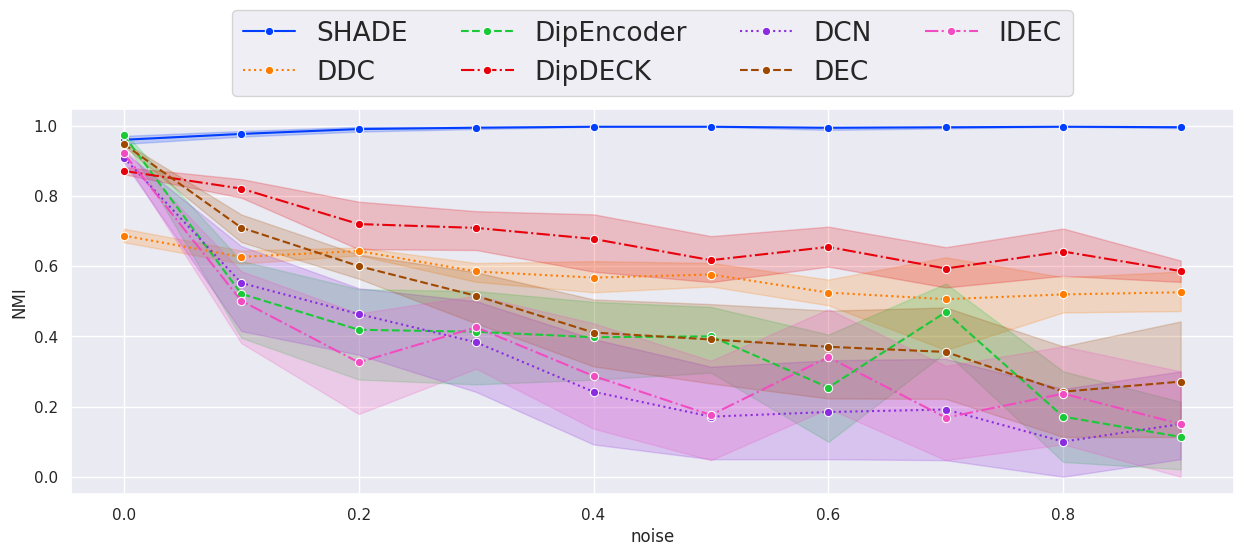

In [451]:
plot_sns(df_noise, "noise", "NMI", None, None)

/tmp/ipykernel_804502/982165924.py:5: UserWarning: The palette list has more values (10) than needed (7), which may not be intended.
  ax = sns.lineplot(


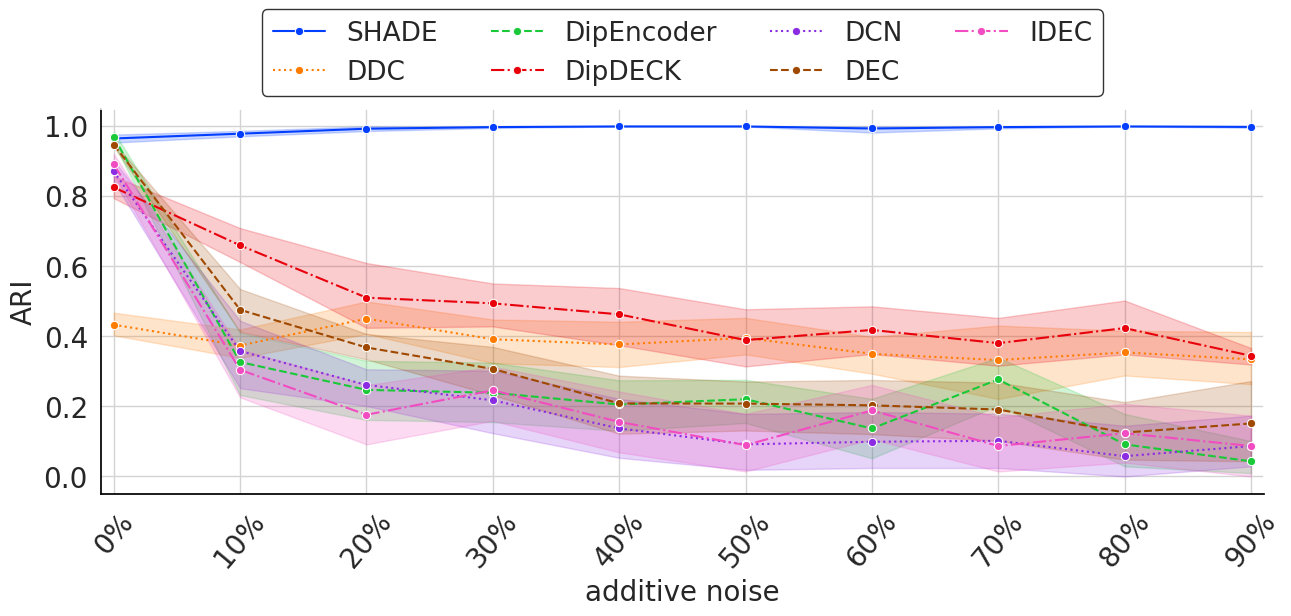

In [452]:
plot_sns(df_noise, "noise", "ARI", None, None)
ax.set_xticks(
    np.arange(0, 1.0, 0.1),
    list(map(lambda x: f"{x}%", np.arange(0, 100, 10))),
    rotation=50,
)
ax.set_xlim([-0.01, 0.91])
# leg.remove()

for item in (
    [ax.title, ax.xaxis.label, ax.yaxis.label] + ax.get_xticklabels() + ax.get_yticklabels()
):
    item.set_fontsize(20)
ax.set_facecolor("white")

ax.set_xlabel("additive noise")

ax.spines["bottom"].set_color("black")
ax.spines["left"].set_color("black")

ax.grid(color="lightgray")

frame = leg.get_frame()
frame.set_facecolor("white")
frame.set_edgecolor("black")

/tmp/ipykernel_804502/440539005.py:5: UserWarning: The palette list has more values (10) than needed (7), which may not be intended.
  ax = sns.lineplot(


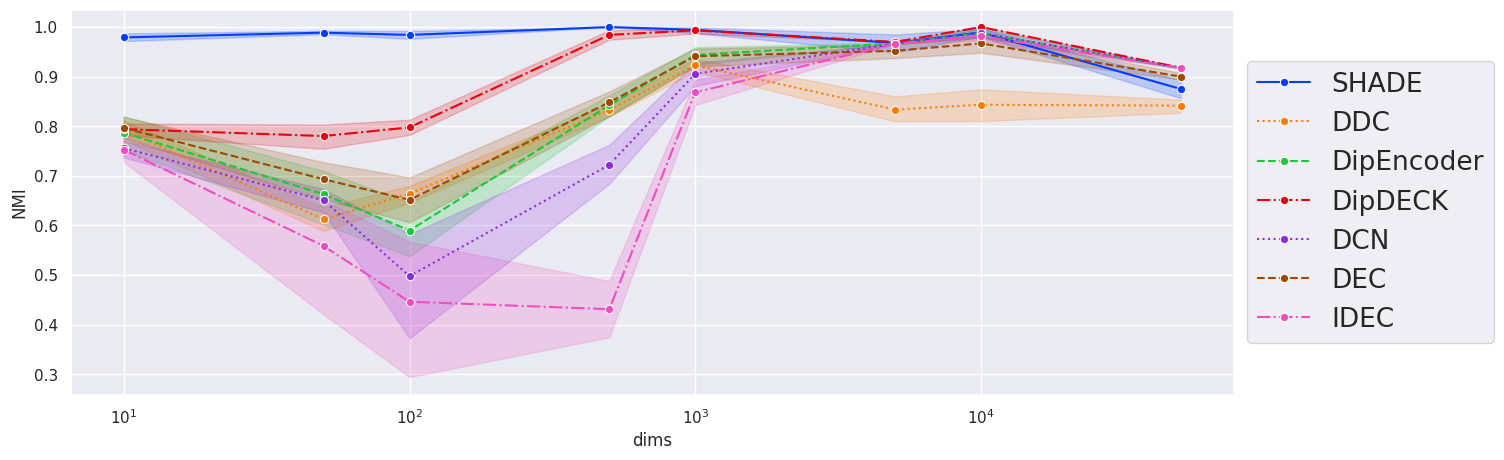

In [319]:
plot_sns(df_dim, "dims", "NMI", None, None)

/tmp/ipykernel_804502/440539005.py:5: UserWarning: The palette list has more values (10) than needed (7), which may not be intended.
  ax = sns.lineplot(


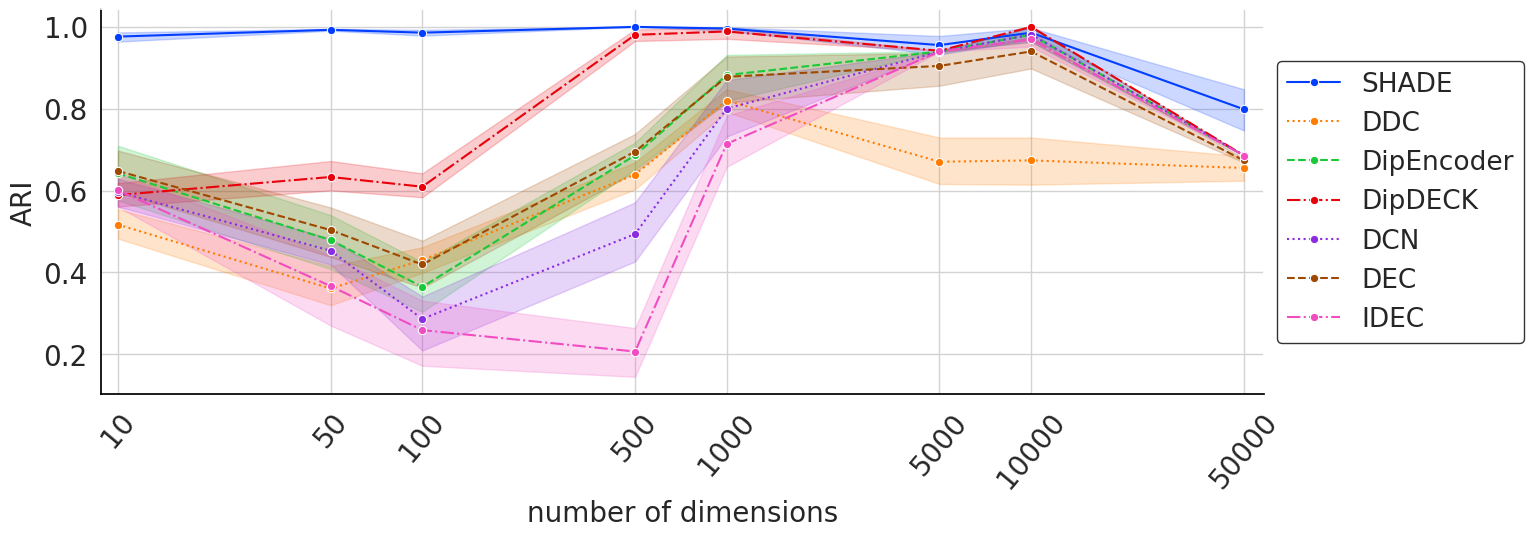

In [320]:
plot_sns(df_dim, "dims", "ARI", None, None)
ax.set_xticks(
    [10, 50, 100, 500, 1000, 5000, 10000, 50000], [10, 50, 100, 500, 1000, 5000, 10000, 50000], rotation=50
)
ax.set_xlim([8.8, 58000])
# ax.set_ylim([None, None])

for item in (
    [ax.title, ax.xaxis.label, ax.yaxis.label] + ax.get_xticklabels() + ax.get_yticklabels()
):
    item.set_fontsize(20)
ax.set_facecolor("white")

ax.set_xlabel("number of dimensions")

ax.spines["bottom"].set_color("black")
ax.spines["left"].set_color("black")

ax.grid(color="lightgray")

frame = leg.get_frame()
frame.set_facecolor("white")
frame.set_edgecolor("black")

In [ ]:
# for alg_name in ALGORITHMS:
#     print(alg_name)
#     noises = []
#     means = []
#     stds = []
#     for dataset, func in DATASETS:
#         noise = float(dataset.split("_")[-1])
#         mean = df2[(alg_name, "ARI")][(dataset, "mean")]
#         std = df2[(alg_name, "ARI")][(dataset, "std")]
#         noises.append(noise)
#         means.append(mean)
#         stds.append(std)

#     sns.lineplot(x=noises, y=means, errorbar=("se", 2))

#     means = np.array(means)
#     stds = np.array(stds)
#     plt.plot(noises, means, label=alg_name)
#     # plt.fill_between(noises, means - stds, means + stds)

# # plt.legend(bbox_to_anchor=(1.1, 1.05))
# # plt.legend(loc="upper center", bbox_to_anchor=(0.5, 1.05), ncols=4, fancybox=True, shadow=True)
# plt.legend(loc="center left", bbox_to_anchor=(1, 0.5))